In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

In [2]:
X, y_true = make_blobs(n_samples=400, centers=4, cluster_std=0.9, random_state=42)

In [21]:
km = KMeans(n_clusters=4,n_init=10,random_state=42)
labels = km.fit_predict(X)
print("Cluster sizes: ",np.bincount(labels))
print("Inertia (total within-cluster distance):",round(km.inertia_, 1))

Cluster sizes:  [100 100 100 100]
Inertia (total within-cluster distance): 620.9


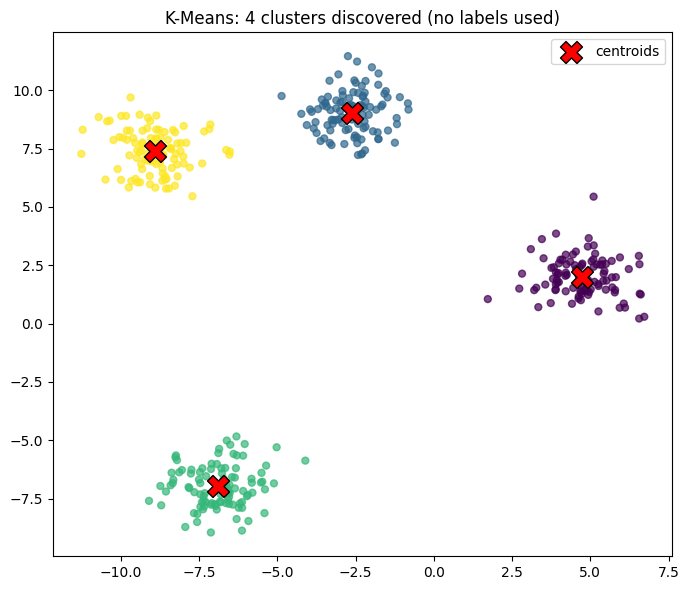

In [22]:
plt.figure(figsize=(7,6))
plt.scatter(X[:,0], X[:,1], c=labels, cmap='viridis', s=25, alpha=0.7)
plt.scatter(km.cluster_centers_[:,0], km.cluster_centers_[:,1],
            c='red', marker='X', s=250, edgecolor='k', label='centroids')
plt.title('K-Means: 4 clusters discovered (no labels used)')
plt.legend(); plt.tight_layout(); plt.savefig('kmeans.png', dpi=110); plt.show()

**How to pick n_clusters**

Silhouette scores by k:
  k=2: 0.598
  k=3: 0.768
  k=4: 0.814
  k=5: 0.709
  k=6: 0.567
  k=7: 0.447
  k=8: 0.334
  k=9: 0.339
  k=10: 0.341
Best k by silhouette: 4


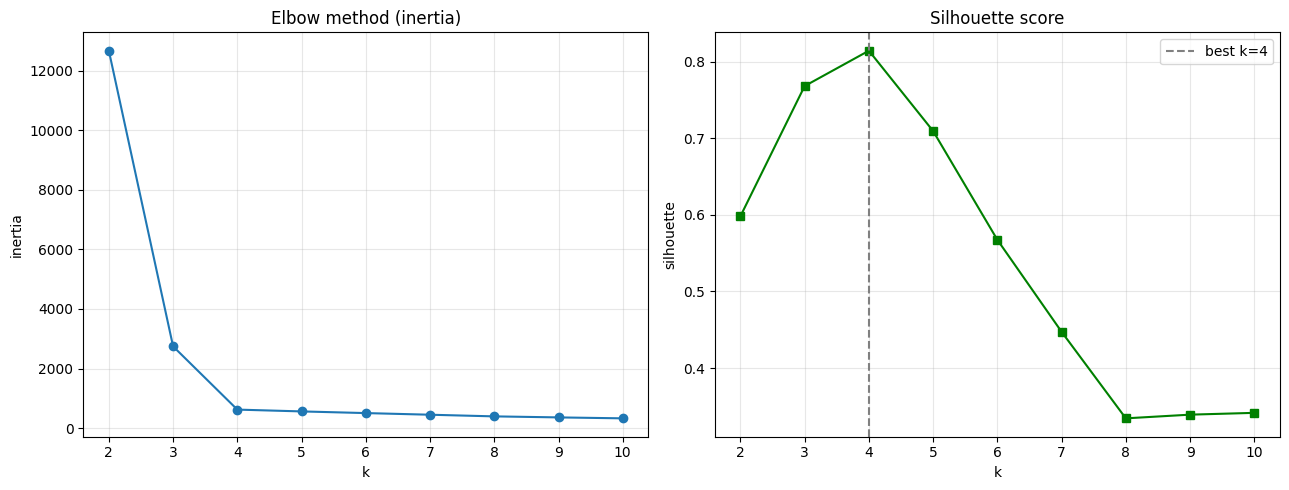

In [16]:
from sklearn.metrics import silhouette_score

X, _ = make_blobs(n_samples=400, centers=4, cluster_std=0.9, random_state=42)
inertias, silhouettes = [], []
ks = range(2,11)
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X)
    inertias.append(km.inertia_)                              # for elbow
    silhouettes.append(silhouette_score(X, km.labels_))



best_k = ks[int(np.argmax(silhouettes))]
print("Silhouette scores by k:")
for k, s in zip(ks, silhouettes):
    print(f"  k={k}: {s:.3f}")
print("Best k by silhouette:", best_k)

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].plot(ks, inertias, 'o-'); ax[0].set_title('Elbow method (inertia)')
ax[0].set_xlabel('k'); ax[0].set_ylabel('inertia'); ax[0].grid(alpha=0.3)
ax[1].plot(ks, silhouettes, 's-', color='green'); ax[1].set_title('Silhouette score')
ax[1].axvline(best_k, color='gray', ls='--', label=f'best k={best_k}')
ax[1].set_xlabel('k'); ax[1].set_ylabel('silhouette'); ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.savefig('choose_k.png', dpi=110); plt.show()
